# PEP 2 - Técnicas Computacionales para Radio Interferometría Astronómica

**Vicente Mieres**

**Instrucciones:**
- Prueba individual
- Responda en este notebook Jupyter
- Puede usar celdas markdown para explicaciones
- Tiempo: 90 minutos
- Puntaje total: 6.0 puntos + 1.0 punto base = 7.0 máximo
- Cada pregunta vale 2 puntos (0-2 puntos cada una)

**Importaciones necesarias:**

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2, fftshift, ifftshift
from scipy.optimize import minimize
from scipy.ndimage import gaussian_filter
import numba
from numba import cuda, prange
import dask.array as da
from dask import delayed
import pytest
import ipytest
import warnings
warnings.filterwarnings('ignore')

# Configuración de plots
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

ipytest.autoconfig()

## Pregunta 1: Análisis de Cobertura UV y Funciones de Transferencia (2.0 puntos)

**Contexto:** En radio interferometría, la cobertura UV (distribución de coordenadas u-v medidas) determina la calidad de la imagen reconstruida. Analizar esta cobertura es crucial para entender las limitaciones de resolución y sensibilidad de una observación.

**Datos proporcionados:**
- Coordenadas UV de múltiples baselines: arrays `u_coords` y `v_coords` (en longitudes de onda)
- Información de los baselines: `baseline_lengths` (distancias físicas en metros)
- Frecuencia de observación: `frequency` (en Hz)

**1.1** (1.0 pts) Implemente la función `analyze_uv_coverage` que analiza la cobertura UV usando numpy broadcasting. La función debe calcular:
- **Distancia UV**: `sqrt(u² + v²)` para cada punto usando broadcasting
- **Histograma 2D** de cobertura UV en un grid regular
- **Función de transferencia radial**: promedio de cobertura en anillos concéntricos (usando broadcasting para calcular distancias desde el origen)
- **Gap más grande**: la distancia máxima entre puntos adyacentes en el espacio UV

**1.2** (1.0 pts) Implemente la función `compute_uvt_coverage` que analiza la cobertura UV-t (cobertura en función del tiempo) para entender cómo evoluciona la cobertura durante la observación. Debe:
- Calcular la cobertura UV en diferentes intervalos de tiempo usando broadcasting
- Identificar gaps temporales en la cobertura
- Calcular la función de transferencia promedio por intervalo temporal
- Use numpy broadcasting para todas las operaciones vectoriales

**Nota:** Use numpy broadcasting eficientemente para evitar loops explícitos. Considere usar `np.meshgrid` o `np.broadcast_arrays` cuando sea apropiado.

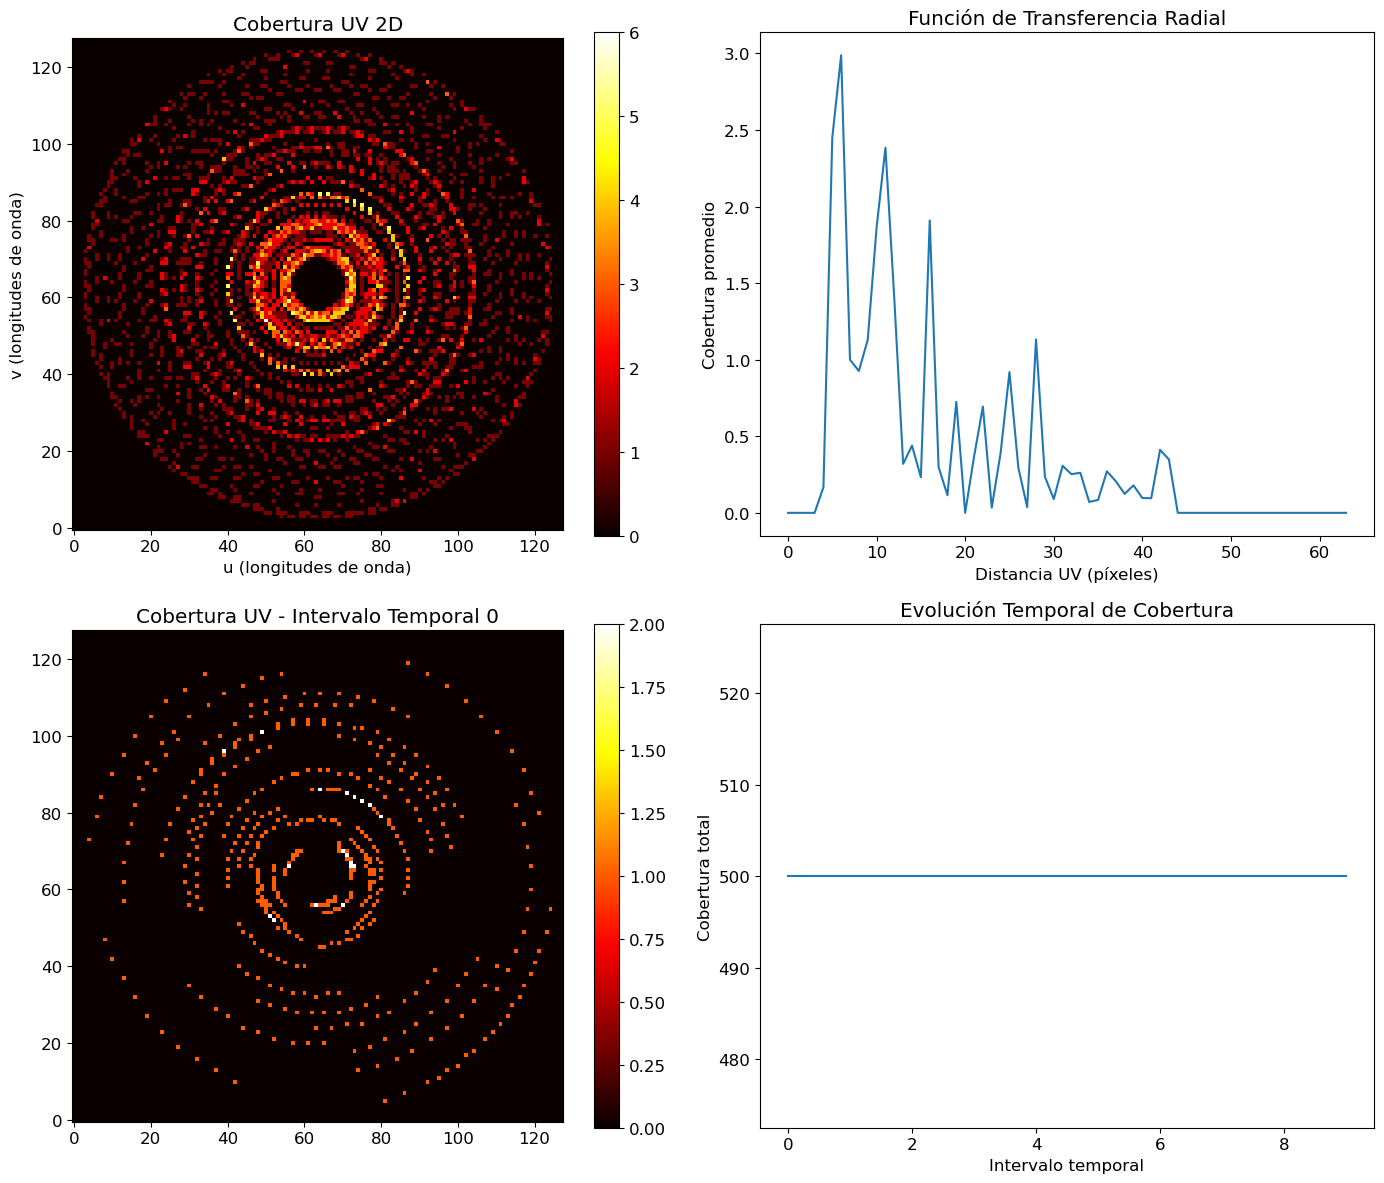

Gap máximo en cobertura UV: 241.10 longitudes de onda


In [18]:
# Datos de ejemplo para la pregunta 1
np.random.seed(42)

# Parámetros de observación
frequency = 1.4e9  # Hz (banda L)
c = 3e8  # velocidad de la luz en m/s
wavelength = c / frequency  # longitud de onda en metros

# Simulación de coordenadas UV de una observación
# Simulamos múltiples baselines observando durante varias horas
n_baselines = 50
n_times = 100  # 100 puntos temporales
n_vis = n_baselines * n_times

# Coordenadas UV (en longitudes de onda)
# Simulamos una cobertura tipo "snapshot" que rota con el tiempo
u_coords = np.zeros(n_vis)
v_coords = np.zeros(n_vis)
times = np.zeros(n_vis)

baseline_lengths = np.random.uniform(100, 1000, n_baselines)  # metros
baseline_angles = np.random.uniform(0, 2*np.pi, n_baselines)  # radianes

for i in range(n_times):
    hour_angle = i * 0.1  # radianes (simula rotación de la Tierra)
    for j in range(n_baselines):
        idx = i * n_baselines + j
        # Proyección del baseline en coordenadas UV (simplificado)
        u_coords[idx] = baseline_lengths[j] / wavelength * np.cos(baseline_angles[j] + hour_angle)
        v_coords[idx] = baseline_lengths[j] / wavelength * np.sin(baseline_angles[j] + hour_angle)
        times[idx] = i

# ============================================
# SU CÓDIGO AQUÍ
# ============================================

def analyze_uv_coverage(u_coords, v_coords, grid_size=128, uv_max=None):
    """
    Analiza la cobertura UV usando numpy broadcasting.
    
    Parámetros:
    -----------
    u_coords, v_coords : arrays 1D
        Coordenadas UV en longitudes de onda
    grid_size : int
        Tamaño del grid para histograma 2D
    uv_max : float, opcional
        Máximo valor UV para el grid. Si None, se calcula automáticamente
        
    Retorna:
    --------
    results : dict
        Diccionario con:
        - 'uv_distances': array 1D con distancias UV
        - 'histogram_2d': array 2D con histograma de cobertura
        - 'radial_transfer_function': array 1D con función de transferencia radial
        - 'max_gap': float con el gap más grande
        - 'uv_grid_u', 'uv_grid_v': arrays 2D con grids UV
    """
    # TODO: Implementar análisis de cobertura UV usando broadcasting
    # 1. Calcular distancias UV usando broadcasting
    # 2. Crear histograma 2D
    # 3. Calcular función de transferencia radial (promedio en anillos)
    # 4. Calcular gap más grande

    # 1. Distancia UV usando operaciones vectorizadas
    # Calcula la distancia radial de cada punto de visibilidad
    uv_distances = np.sqrt(u_coords**2 + v_coords**2)
    # calculo de uvmax
    if uv_max is None:
        uv_max = np.max(uv_distances) * 1.05 # margen
        
    # 2. Histograma 2D de cobertura UV
    bins = np.linspace(-uv_max, uv_max, grid_size + 1)
    histogram_2d, x_edges, y_edges = np.histogram2d(u_coords, v_coords, bins=bins)
    
    # 3. Función de transferencia radial (Broadcasting)
    u_centers = (x_edges[:-1] + x_edges[1:]) / 2
    v_centers = (y_edges[:-1] + y_edges[1:]) / 2
    grid_u, grid_v = np.meshgrid(u_centers, v_centers, indexing='ij')
    # distancia radial
    grid_r = np.sqrt(grid_u**2 + grid_v**2)
    
    # anillos para el perfil radial
    max_r_grid = np.max(grid_r)
    n_radial_bins = grid_size // 2
    radial_bins = np.linspace(0, max_r_grid, n_radial_bins + 1)

    bin_indices = np.digitize(grid_r.ravel(), radial_bins)
    
    # bincount para sumar la cobertura en cada anillo y contar pixeles por anillo
    hist_flat = histogram_2d.ravel()
    
    # Suma de pesos por anillo
    radial_sum = np.bincount(bin_indices, weights=hist_flat, minlength=len(radial_bins)+1)
    # Cantidad de pixeles por anillo
    pixel_counts = np.bincount(bin_indices, minlength=len(radial_bins)+1)
    
    # Promedio evitando división por cero
    with np.errstate(invalid='ignore', divide='ignore'):
        radial_profile = radial_sum / pixel_counts
        
    radial_transfer_function = np.nan_to_num(radial_profile)[1:len(radial_bins)]

    # 4. Gap más grande 
    sorted_dists = np.sort(uv_distances)
    gaps = np.diff(sorted_dists)
    max_gap = np.max(gaps) if len(gaps) > 0 else 0.0

    return {
        'uv_distances': uv_distances,
        'histogram_2d': histogram_2d,
        'radial_transfer_function': radial_transfer_function,
        'max_gap': max_gap,
        'uv_grid_u': grid_u,
        'uv_grid_v': grid_v
    }

    # pass

def compute_uvt_coverage(u_coords, v_coords, times, n_time_bins=10, grid_size=128):
    """
    Analiza la cobertura UV-t (cobertura en función del tiempo).
    
    Parámetros:
    -----------
    u_coords, v_coords : arrays 1D
        Coordenadas UV
    times : array 1D
        Tiempos de observación
    n_time_bins : int
        Número de intervalos temporales
    grid_size : int
        Tamaño del grid UV
        
    Retorna:
    --------
    results : dict
        Diccionario con:
        - 'time_bins': array 1D con límites de intervalos temporales
        - 'coverage_per_bin': lista de arrays 2D con cobertura por intervalo
        - 'transfer_function_per_bin': lista de arrays 1D con función de transferencia por intervalo
        - 'temporal_gaps': array con gaps temporales identificados
    """
    # TODO: Implementar análisis UV-t usando broadcasting
    # 1. Dividir datos en intervalos temporales
    # 2. Calcular cobertura UV para cada intervalo usando broadcasting
    # 3. Calcular función de transferencia por intervalo
    # 4. Identificar gaps temporales

    # 1. Configuración de Bins
    uv_max = np.max(np.sqrt(u_coords**2 + v_coords**2)) * 1.05
    uv_bins = np.linspace(-uv_max, uv_max, grid_size + 1)
    
    # Límites Temporales
    t_min, t_max = np.min(times), np.max(times)
    time_bins = np.linspace(t_min, t_max * 1.0001, n_time_bins + 1)
    
    # 2. cobertura para cada intervalo con bc
    data_3d = np.vstack((u_coords, v_coords, times)).T
    
    H_3d, edges = np.histogramdd(data_3d, bins=[uv_bins, uv_bins, time_bins])
    
    # 3. función de transferencia
    u_centers = (edges[0][:-1] + edges[0][1:]) / 2
    v_centers = (edges[1][:-1] + edges[1][1:]) / 2
    
    grid_u, grid_v = np.meshgrid(u_centers, v_centers, indexing='ij')
    grid_r = np.sqrt(grid_u**2 + grid_v**2)
    
    max_r = np.max(grid_r)
    n_radial_bins = grid_size // 2
    radial_bins = np.linspace(0, max_r, n_radial_bins + 1)
    pixel_ring_indices = np.digitize(grid_r.ravel(), radial_bins)
    
    # Cantidad de pixeles por anillo (denominador constante)
    pixel_counts_per_ring = np.bincount(pixel_ring_indices, minlength=len(radial_bins)+1)
    
    # 4. Procesamiento por intervalo temporal
    coverage_per_bin = []
    transfer_function_per_bin = []
    
    # Iteramos sobre los bines de tiempo (esto es rápido, son solo ~10 iteraciones)
    for t in range(n_time_bins):
        # shape: (grid_size, grid_size)
        uv_slice = H_3d[:, :, t]
        coverage_per_bin.append(uv_slice)
        
        # perfil radial 
        radial_sum = np.bincount(pixel_ring_indices, weights=uv_slice.ravel(), minlength=len(radial_bins)+1)
        
        # Promedio evitando división por cero
        with np.errstate(divide='ignore', invalid='ignore'):
            profile = radial_sum / pixel_counts_per_ring
            
        # Limpieza de NaNs
        tf = np.nan_to_num(profile)[1:len(radial_bins)]
        transfer_function_per_bin.append(tf)

    # 5. Gaps Temporales
    unique_times = np.sort(np.unique(times))
    dt = np.diff(unique_times)
    
    # Definimos un "gap" como un salto inusualmente grande
    # Por ejemplo, cualquier salto > 2 veces la mediana del tiempo de integración
    median_dt = np.median(dt)
    temporal_gaps = dt[dt > 2 * median_dt]
    
    # Si no hay gaps significativos, devolvemos array vacío o con 0
    if len(temporal_gaps) == 0:
        temporal_gaps = np.array([0.0])

    return {
        'time_bins': time_bins,
        'coverage_per_bin': coverage_per_bin,
        'transfer_function_per_bin': transfer_function_per_bin,
        'temporal_gaps': temporal_gaps
    }

    # pass

#============================================
#Código de prueba (ejecutar después de implementar)
#============================================
# Análisis de cobertura UV
uv_analysis = analyze_uv_coverage(u_coords, v_coords)

# Análisis UV-t
uvt_analysis = compute_uvt_coverage(u_coords, v_coords, times)

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Cobertura UV 2D
im1 = axes[0, 0].imshow(uv_analysis['histogram_2d'], origin='lower', cmap='hot')
axes[0, 0].set_title('Cobertura UV 2D')
axes[0, 0].set_xlabel('u (longitudes de onda)')
axes[0, 0].set_ylabel('v (longitudes de onda)')
plt.colorbar(im1, ax=axes[0, 0])

# Función de transferencia radial
axes[0, 1].plot(uv_analysis['radial_transfer_function'])
axes[0, 1].set_title('Función de Transferencia Radial')
axes[0, 1].set_xlabel('Distancia UV (píxeles)')
axes[0, 1].set_ylabel('Cobertura promedio')

#Cobertura UV-t (primer intervalo)
im2 = axes[1, 0].imshow(uvt_analysis['coverage_per_bin'][0], origin='lower', cmap='hot')
axes[1, 0].set_title('Cobertura UV - Intervalo Temporal 0')
plt.colorbar(im2, ax=axes[1, 0])

# Evolución temporal de la cobertura
coverage_evolution = [np.sum(cov) for cov in uvt_analysis['coverage_per_bin']]
axes[1, 1].plot(coverage_evolution)
axes[1, 1].set_title('Evolución Temporal de Cobertura')
axes[1, 1].set_xlabel('Intervalo temporal')
axes[1, 1].set_ylabel('Cobertura total')

plt.tight_layout()
plt.show()

print(f"Gap máximo en cobertura UV: {uv_analysis['max_gap']:.2f} longitudes de onda")

## Ejemplo para mostrar los gaps temporales

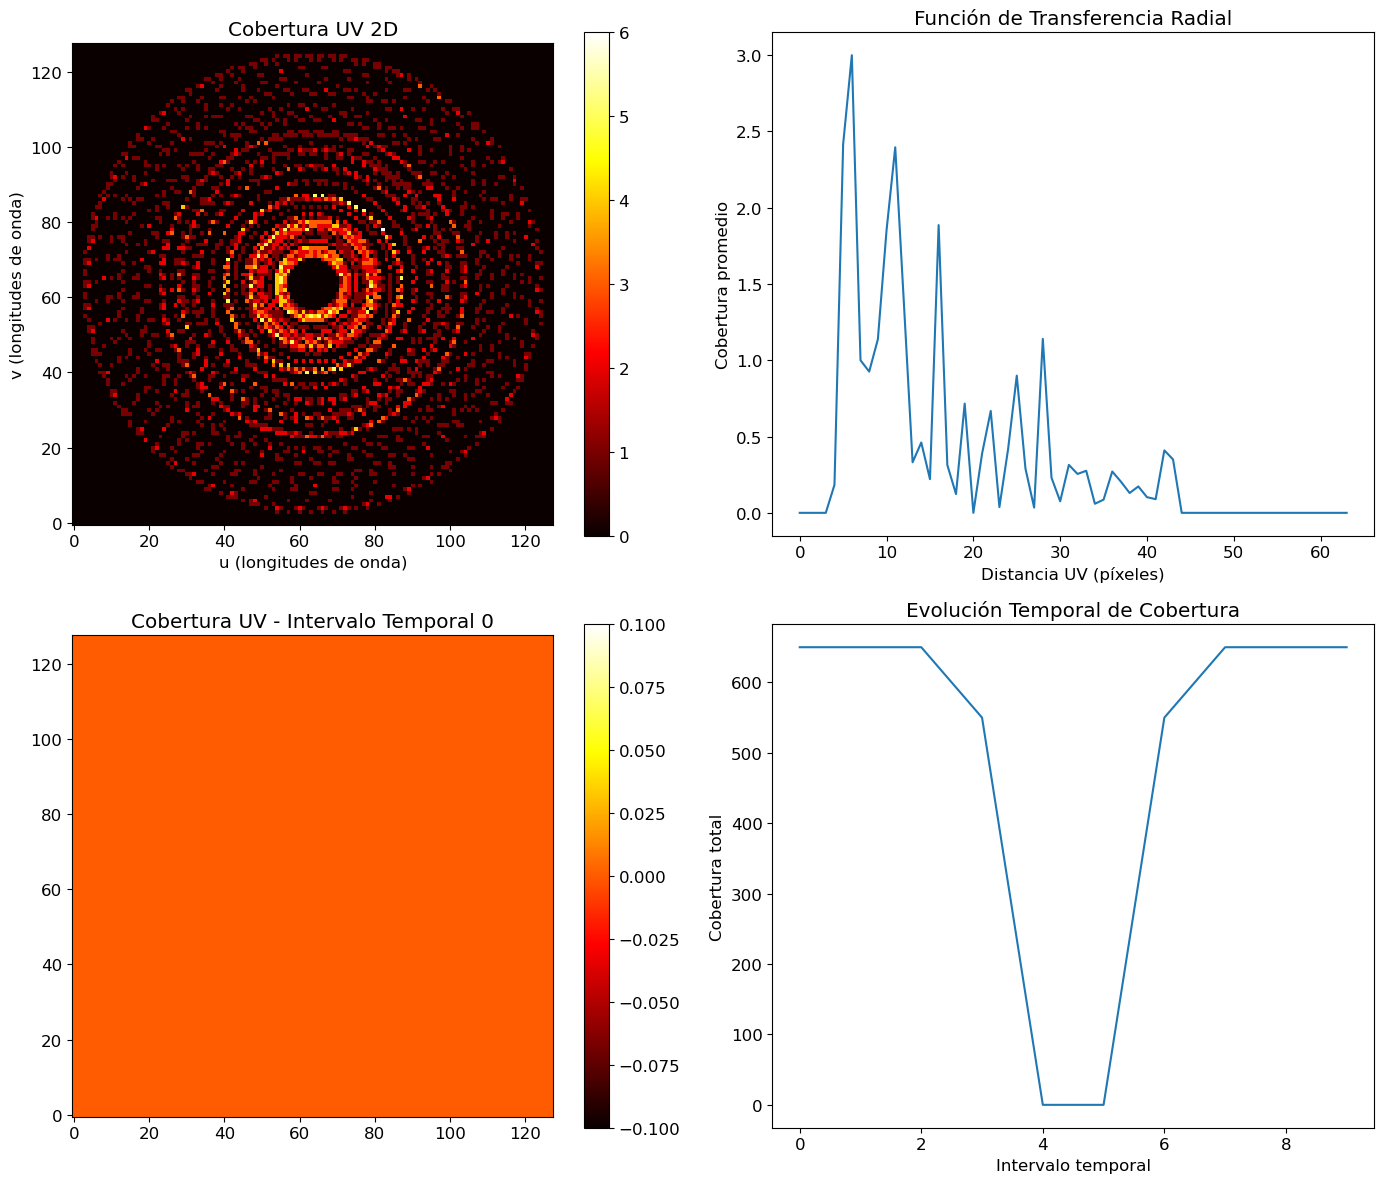

Gap máximo en cobertura UV: 241.10 longitudes de onda


In [19]:
# ============================================
# DATOS DE EJEMPLO CON GAP TEMPORAL
# ============================================
np.random.seed(42)

# Parámetros (igual que antes)
frequency = 1.4e9
c = 3e8
wavelength = c / frequency
n_baselines = 50
n_times = 100
n_vis = n_baselines * n_times

# gap
times_part1 = np.arange(50, dtype=float)
times_part2 = np.arange(50, dtype=float) + 80 
observation_times = np.concatenate([times_part1, times_part2]) 

# Arrays de datos
u_coords = np.zeros(n_vis)
v_coords = np.zeros(n_vis)
times = np.zeros(n_vis)

baseline_lengths = np.random.uniform(100, 1000, n_baselines)
baseline_angles = np.random.uniform(0, 2*np.pi, n_baselines)

for i in range(n_times):
    t_current = observation_times[i]
    
    # La rotación de la Tierra (hour_angle) debe respetar este salto de tiempo
    hour_angle = t_current * 0.1 
    
    for j in range(n_baselines):
        idx = i * n_baselines + j
        
        # Calculamos U y V basados en el tiempo real (con salto)
        u_coords[idx] = baseline_lengths[j] / wavelength * np.cos(baseline_angles[j] + hour_angle)
        v_coords[idx] = baseline_lengths[j] / wavelength * np.sin(baseline_angles[j] + hour_angle)
        
        # IMPORTANTE: Guardamos el tiempo discontinuo en el array
        times[idx] = t_current

# ============================================
# #Código de prueba (ejecutar después de implementar)
# #============================================
# Análisis de cobertura UV
uv_analysis = analyze_uv_coverage(u_coords, v_coords)

# Análisis UV-t
uvt_analysis = compute_uvt_coverage(u_coords, v_coords, times)

# Visualización
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Cobertura UV 2D
im1 = axes[0, 0].imshow(uv_analysis['histogram_2d'], origin='lower', cmap='hot')
axes[0, 0].set_title('Cobertura UV 2D')
axes[0, 0].set_xlabel('u (longitudes de onda)')
axes[0, 0].set_ylabel('v (longitudes de onda)')
plt.colorbar(im1, ax=axes[0, 0])

# Función de transferencia radial
axes[0, 1].plot(uv_analysis['radial_transfer_function'])
axes[0, 1].set_title('Función de Transferencia Radial')
axes[0, 1].set_xlabel('Distancia UV (píxeles)')
axes[0, 1].set_ylabel('Cobertura promedio')

#Cobertura UV-t (primer intervalo)
im2 = axes[1, 0].imshow(uvt_analysis['coverage_per_bin'][5], origin='lower', cmap='hot')
axes[1, 0].set_title('Cobertura UV - Intervalo Temporal 0')
plt.colorbar(im2, ax=axes[1, 0])

# Evolución temporal de la cobertura
coverage_evolution = [np.sum(cov) for cov in uvt_analysis['coverage_per_bin']]
axes[1, 1].plot(coverage_evolution)
axes[1, 1].set_title('Evolución Temporal de Cobertura')
axes[1, 1].set_xlabel('Intervalo temporal')
axes[1, 1].set_ylabel('Cobertura total')

plt.tight_layout()
plt.show()

print(f"Gap máximo en cobertura UV: {uv_analysis['max_gap']:.2f} longitudes de onda")

## Pregunta 2: Optimización de Cálculos Geométricos con Numba (2.0 puntos)

**Contexto:** En radio interferometría, necesitamos calcular frecuentemente propiedades geométricas de los baselines (distancias, ángulos, proyecciones) para entender la cobertura UV y calibrar las observaciones. Estos cálculos pueden ser costosos cuando se tienen miles de baselines y múltiples tiempos de observación.

**Datos proporcionados:**
- Posiciones de antenas: `antenna_positions` (array 3D: [n_antennas, 3] con coordenadas x, y, z en metros)
- Tiempos de observación: `times` (array 1D)
- Coordenadas del objeto observado: `source_ra`, `source_dec` (en radianes)
- Posición del observatorio: `observatory_lat`, `observatory_lon` (en radianes)

**2.1** (1.0 pts) Implemente una función `compute_baseline_properties_numba_cpu` que calcule propiedades de baselines usando Numba con decorador `@numba.jit` para optimización en CPU. La función debe calcular para cada par de antenas y cada tiempo:
- **Longitud del baseline**: distancia 3D entre dos antenas
- **Proyección UV**: coordenadas u, v proyectadas considerando la rotación de la Tierra
- **Ángulo del baseline**: ángulo azimutal del baseline
- Comparar el tiempo de ejecución con una versión numpy pura

**2.2** (1.0 pts) Si tiene acceso a GPU CUDA, implemente `compute_baseline_properties_numba_cuda` usando el decorador `@cuda.jit`. Si no tiene GPU, explique cómo se implementaría y qué modificaciones serían necesarias respecto a la versión CPU (paralelización por threads, manejo de memoria compartida, reducciones, etc.).

**Nota:** Para la versión CUDA, puede implementar un kernel simplificado o explicar la implementación completa. Considere que cada thread puede procesar un par de antenas o un tiempo específico.

Tiempo numpy: 0.0334 s
Tiempo Numba CPU: 0.1698 s
Tiempo Cuda: 0.0145 s
Speedup numpy/numba: 0.20x
Speedup numpy/cuda: 2.30x
Speedup numba/cuda: 11.70x


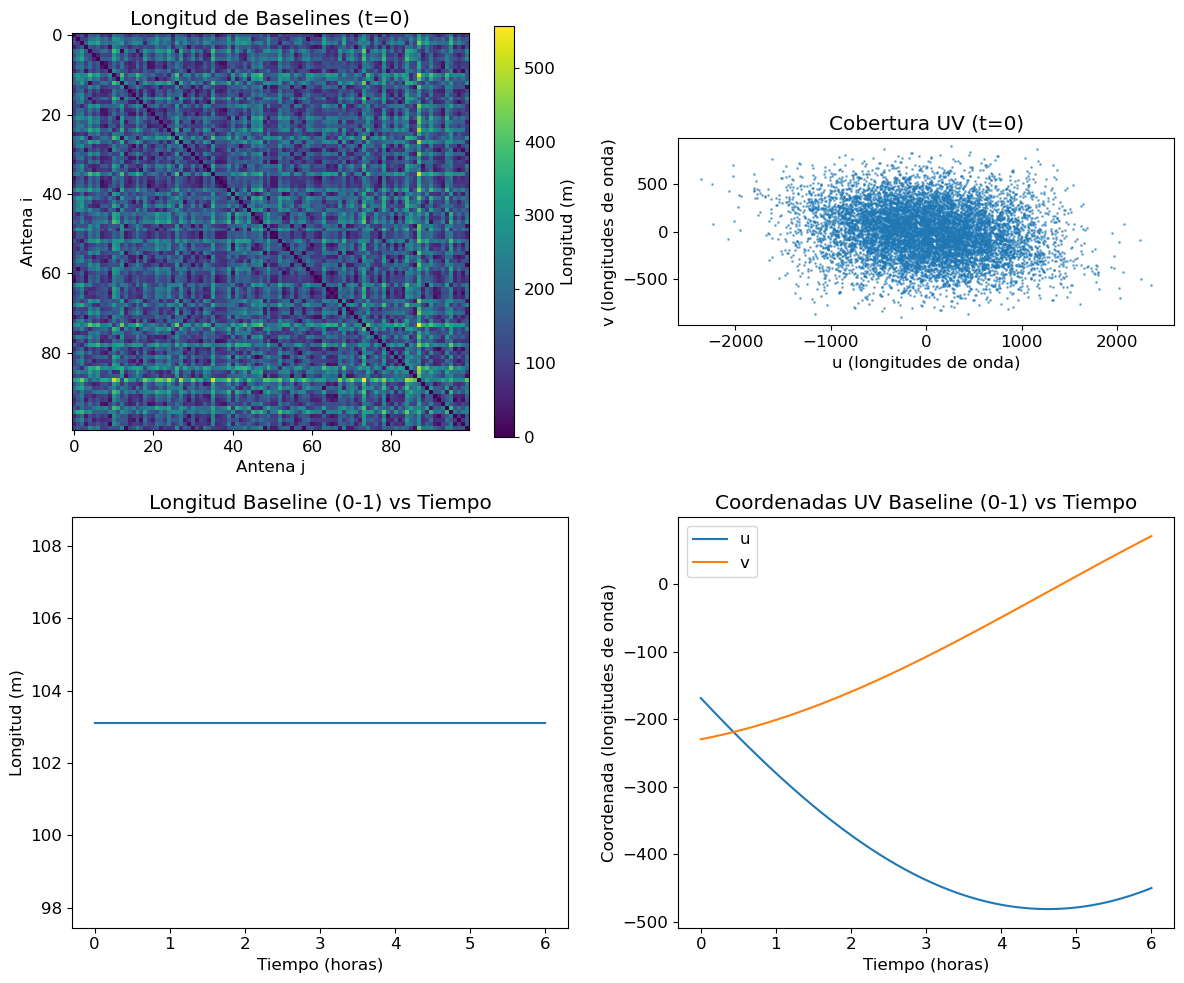

In [20]:
# Datos de ejemplo para la pregunta 2
np.random.seed(42)

# Parámetros del observatorio (ejemplo: ALMA)
observatory_lat = -23.029 * np.pi / 180  # radianes
observatory_lon = -67.755 * np.pi / 180   # radianes

# Simulación de array de antenas (configuración compacta)
n_antennas = 100
antenna_positions = np.random.randn(n_antennas, 3) * 100  # metros (distribución aleatoria)
# Asegurar que las antenas estén en un plano (z pequeño)
antenna_positions[:, 2] = np.random.randn(n_antennas) * 10

# Tiempos de observación (simulación de 6 horas)
n_times = 360  # un punto cada minuto
times = np.linspace(0, 6, n_times)  # horas desde medianoche

# Fuente observada (ejemplo: centro galáctico)
source_ra = 266.4167 * np.pi / 180   # radianes
source_dec = -29.0078 * np.pi / 180   # radianes

# Frecuencia de observación
frequency = 1.4e9  # Hz
c = 3e8  # m/s
wavelength = c / frequency  # metros

# ============================================
# SU CÓDIGO AQUÍ
# ============================================

# Versión numpy pura (referencia)
def compute_baseline_properties_numpy(antenna_positions, times, source_ra, source_dec,
                                     observatory_lat, observatory_lon, wavelength):
    """
    Calcula propiedades de baselines usando numpy puro.

    Parámetros:
    -----------
    antenna_positions : array 2D [n_antennas, 3]
        Posiciones de las antenas en metros (x, y, z)
    times : array 1D (horas)
        Tiempos de observación
    source_ra, source_dec : float (radianes)
        Coordenadas de la fuente
    observatory_lat, observatory_lon : float (radianes)
        Coordenadas del observatorio
    wavelength : float
        Longitud de onda en metros
    
    Retorna:
    --------
    dict con:
        - 'baseline_lengths': [n_ant, n_ant, n_times]
        - 'u_coords': [n_ant, n_ant, n_times]
        - 'v_coords': [n_ant, n_ant, n_times]
        - 'baseline_angles': [n_ant, n_ant, n_times]
    """

    n_ant = antenna_positions.shape[0]
    n_times = len(times)

    # Salidas
    baseline_lengths = np.zeros((n_ant, n_ant, n_times))
    u_coords = np.zeros_like(baseline_lengths)
    v_coords = np.zeros_like(baseline_lengths)
    baseline_angles = np.zeros_like(baseline_lengths)

    omega_earth = 7.2921150e-5  # rad/s

    # Diferencias entre antenas
    dx = antenna_positions[:, np.newaxis, 0] - antenna_positions[np.newaxis, :, 0]
    dy = antenna_positions[:, np.newaxis, 1] - antenna_positions[np.newaxis, :, 1]
    dz = antenna_positions[:, np.newaxis, 2] - antenna_positions[np.newaxis, :, 2]

    # Longitud del baseline
    baseline_lengths[:, :, :] = np.sqrt(dx**2 + dy**2 + dz**2)[..., np.newaxis]

    # Ángulos de baseline (azimut)
    baseline_angles[:, :, :] = np.arctan2(dy, dx)[..., np.newaxis]

    sin_dec = np.sin(source_dec)
    cos_dec = np.cos(source_dec)

    # Procesar cada tiempo
    for t_idx, t in enumerate(times):

        # horas -> segundos
        t_sec = t * 3600.0

        # Ángulo horario
        H = omega_earth * t_sec + observatory_lon - source_ra
        sin_H = np.sin(H)
        cos_H = np.cos(H)

        # Matriz de rotación UVW
        R = np.array([
            [ sin_H,              cos_H,            0.0     ],
            [-sin_dec*cos_H,      sin_dec*sin_H,   cos_dec ],
            [ cos_dec*cos_H,     -cos_dec*sin_H,   sin_dec ]
        ])

        d = np.stack([dx, dy, dz], axis=-1)   # shape (n_ant, n_ant, 3)

        uvw = d @ R.T   # shape (n_ant, n_ant, 3)

        # Extraer u, v (normalizados a longitudes de onda)
        u_coords[:,:,t_idx] = uvw[:,:,0]
        v_coords[:,:,t_idx] = uvw[:,:,1] 
    
    return {
        "baseline_lengths": baseline_lengths,
        "u_coords": u_coords,
        "v_coords": v_coords,
        "baseline_angles": baseline_angles
    }

#Versión optimizada con Numba CPU
@numba.jit(nopython=True)
def compute_baseline_properties_numba_cpu(antenna_positions, times, source_ra, source_dec,
                                         observatory_lat, observatory_lon, wavelength,
                                         baseline_lengths, u_coords, v_coords, baseline_angles):
    """
    Calcula propiedades de baselines usando Numba JIT en CPU.
    
    Parámetros:
    -----------
    antenna_positions : array 2D [n_antennas, 3]
        Posiciones de las antenas
    times : array 1D
        Tiempos de observación
    source_ra, source_dec, observatory_lat, observatory_lon : float
        Coordenadas
    wavelength : float
        Longitud de onda
    baseline_lengths, u_coords, v_coords, baseline_angles : arrays 3D de salida
        Arrays pre-allocados para resultados [n_antennas, n_antennas, n_times]
        
    Nota: Esta función modifica los arrays de salida in-place.
    """
    # TODO: Implementar con loops optimizados por Numba
    # Calcular para cada par de antenas (i, j) y cada tiempo t:
    # - Longitud del baseline 3D
    # - Proyección UV considerando rotación de la Tierra
    # - Ángulo del baseline

    n_ant = antenna_positions.shape[0]
    n_times = times.shape[0]

    omega_earth = 7.2921150e-5  # rad/s

    sin_dec = np.sin(source_dec)
    cos_dec = np.cos(source_dec)

    # diferencias entre antenas
    dx = np.zeros((n_ant, n_ant))
    dy = np.zeros((n_ant, n_ant))
    dz = np.zeros((n_ant, n_ant))

    for i in range(n_ant):
        xi = antenna_positions[i, 0]
        yi = antenna_positions[i, 1]
        zi = antenna_positions[i, 2]

        for j in range(n_ant):
            dx[i, j] = xi - antenna_positions[j, 0]
            dy[i, j] = yi - antenna_positions[j, 1]
            dz[i, j] = zi - antenna_positions[j, 2]

    # baseblines -> longitud y ángulos
    for i in range(n_ant):
        for j in range(n_ant):
            length = np.sqrt(dx[i, j] * dx[i, j] + dy[i, j] * dy[i, j] + dz[i, j] * dz[i, j])
            angle  = np.arctan2(dy[i, j], dx[i, j])

            for t_idx in range(n_times):
                baseline_lengths[i, j, t_idx] = length
                baseline_angles[i, j, t_idx] = angle

    # Procesar cada tiempo
    for t_idx in range(n_times):

        # horas → segundos
        t_sec = times[t_idx] * 3600.0

        # angulo horario (HA)
        H = omega_earth * t_sec + observatory_lon - source_ra
        sin_H = np.sin(H)
        cos_H = np.cos(H)

        # Matriz de rotación UVW (expandida para Numba)
        R00 = sin_H;               R01 = cos_H;               R02 = 0.0
        R10 = -sin_dec*cos_H;      R11 = sin_dec*sin_H;       R12 = cos_dec
        R20 =  cos_dec*cos_H;      R21 = -cos_dec*sin_H;      R22 = sin_dec

        # Para cada baseline
        for i in range(n_ant):
            for j in range(n_ant):

                # Producto con la matriz UVW
                u = R00*dx[i,j] + R01*dy[i,j] + R02*dz[i,j]
                v = R10*dx[i,j] + R11*dy[i,j] + R12*dz[i,j]

                u_coords[i, j, t_idx] = u 
                v_coords[i, j, t_idx] = v 

@cuda.jit
def _kernel_uv_from_dxdy(dx, dy, dz, sin_H, cos_H, sin_lat, cos_lat, wavelength, u_out, v_out):
    idx = cuda.grid(1)
    total = dx.shape[0] * dx.shape[1] * sin_H.shape[0]
    stride = cuda.gridsize(1)

    n_ant_i = dx.shape[0]
    n_ant_j = dx.shape[1]
    n_times = sin_H.shape[0]

    while idx < total:
        t = idx % n_times
        tmp = idx // n_times
        j = tmp % n_ant_j
        i = tmp // n_ant_j

        dx_ = dx[i, j]
        dy_ = dy[i, j]
        dz_ = dz[i, j]

        sH = sin_H[t]
        cH = cos_H[t]

        u = dx_ * sH + dy_ * cH
        v = -dx_ * sin_lat * cH + dy_ * sin_lat * sH + dz_ * cos_lat

        u_out[i, j, t] = u / wavelength
        v_out[i, j, t] = v / wavelength

        idx += stride

#Versión CUDA (opcional si tiene GPU)
def compute_baseline_properties_numba_cuda(antenna_positions, times, source_ra, source_dec,
                                          observatory_lat, observatory_lon, wavelength,
                                          baseline_lengths, u_coords, v_coords, baseline_angles,
                                          threads_per_block=256):
    """
    Kernel CUDA para calcular propiedades de baselines.
    
    Cada thread puede procesar una combinación (i, j, t) o usar una estrategia diferente.
    """
    # TODO: Implementar kernel CUDA
    # Consideraciones:
    # - Paralelización: cada thread procesa un (i, j, t) o un bloque de tiempos
    # - Memoria compartida para posiciones de antenas
    # - Reducciones si es necesario
    
    n_ant = antenna_positions.shape[0]
    n_times = times.shape[0]

    # Diferencias entre antenas
    dx = np.empty((n_ant, n_ant))
    dy = np.empty((n_ant, n_ant))
    dz = np.empty((n_ant, n_ant))
    for i in range(n_ant):
        xi = antenna_positions[i, 0]
        yi = antenna_positions[i, 1]
        zi = antenna_positions[i, 2]
        # vectorizado por j
        dx[i, :] = antenna_positions[:, 0] - xi
        dy[i, :] = antenna_positions[:, 1] - yi
        dz[i, :] = antenna_positions[:, 2] - zi

    # Baseline longitudes y ángulos 
    baseline_lengths = np.sqrt(dx**2 + dy**2 + dz**2)
    baseline_angles = np.arctan2(dy, dx)

    baseline_lengths_3d = np.repeat(baseline_lengths[:, :, np.newaxis], n_times, axis=2)
    baseline_angles_3d = np.repeat(baseline_angles[:, :, np.newaxis], n_times, axis=2)

    omega_earth = np.float64(7.2921150e-5)

    t_secs = times * 3600.0
    H = omega_earth * t_secs + observatory_lon - source_ra
    sin_H = np.sin(H)
    cos_H = np.cos(H)

    sin_lat = np.sin(observatory_lat)
    cos_lat = np.cos(observatory_lat)

    # pasar a gpu
    dx_dev = cuda.to_device(dx)
    dy_dev = cuda.to_device(dy)
    dz_dev = cuda.to_device(dz)

    sin_H_dev = cuda.to_device(sin_H)
    cos_H_dev = cuda.to_device(cos_H)

    u_dev = cuda.device_array((n_ant, n_ant, n_times))
    v_dev = cuda.device_array((n_ant, n_ant, n_times))

    # kernel
    total_threads = n_ant * n_ant * n_times
    blocks_per_grid = (total_threads + threads_per_block - 1) // threads_per_block

    _kernel_uv_from_dxdy[blocks_per_grid, threads_per_block](
        dx_dev, dy_dev, dz_dev,
        sin_H_dev, cos_H_dev,
        sin_lat, cos_lat,
        wavelength,
        u_dev, v_dev
    )

    cuda.synchronize()

    u_host = u_dev.copy_to_host()
    v_host = v_dev.copy_to_host()

    return {
        "baseline_lengths": baseline_lengths_3d,
        "u_coords": u_host,
        "v_coords": v_host,
        "baseline_angles": baseline_angles_3d
    }

# ============================================
# Código de prueba y comparación de rendimiento
# ============================================
import time

# Pre-allocar arrays de salida
n_antennas = antenna_positions.shape[0]
n_times = len(times)

baseline_lengths_numpy = np.zeros((n_antennas, n_antennas, n_times))
u_coords_numpy = np.zeros((n_antennas, n_antennas, n_times))
v_coords_numpy = np.zeros((n_antennas, n_antennas, n_times))
baseline_angles_numpy = np.zeros((n_antennas, n_antennas, n_times))

baseline_lengths_numba = np.zeros((n_antennas, n_antennas, n_times))
u_coords_numba = np.zeros((n_antennas, n_antennas, n_times))
v_coords_numba = np.zeros((n_antennas, n_antennas, n_times))
baseline_angles_numba = np.zeros((n_antennas, n_antennas, n_times))

baseline_lengths_cuda = np.zeros((n_antennas, n_antennas, n_times))
u_coords_cuda = np.zeros((n_antennas, n_antennas, n_times))
v_coords_cuda = np.zeros((n_antennas, n_antennas, n_times))
baseline_angles_cuda = np.zeros((n_antennas, n_antennas, n_times))



# Calentamiento de Numba
compute_baseline_properties_numba_cpu(
    antenna_positions[:10], times[:10], source_ra, source_dec,
    observatory_lat, observatory_lon, wavelength,
    baseline_lengths_numba[:10, :10, :10],
    u_coords_numba[:10, :10, :10],
    v_coords_numba[:10, :10, :10],
    baseline_angles_numba[:10, :10, :10])

# canlentamiento cuda
_ = compute_baseline_properties_numba_cuda(
    antenna_positions[:10], times[:10], source_ra, source_dec,
    observatory_lat, observatory_lon, wavelength,
    baseline_lengths_numba[:10, :10, :10],
    u_coords_numba[:10, :10, :10],
    v_coords_numba[:10, :10, :10],
    baseline_angles_numba[:10, :10, :10],
    threads_per_block=256)

# Comparación de tiempos
start = time.time()
results_numpy = compute_baseline_properties_numpy(
    antenna_positions, times, source_ra, source_dec,
    observatory_lat, observatory_lon, wavelength)
time_numpy = time.time() - start

start = time.time()
compute_baseline_properties_numba_cpu(
    antenna_positions, times, source_ra, source_dec,
    observatory_lat, observatory_lon, wavelength,
    baseline_lengths_numba, u_coords_numba, v_coords_numba, baseline_angles_numba)
time_numba = time.time() - start

start = time.time()
results_cuda = compute_baseline_properties_numba_cuda(
    antenna_positions, times, source_ra, source_dec,
    observatory_lat, observatory_lon, wavelength, 
    baseline_angles=baseline_angles_cuda, 
    baseline_lengths=baseline_lengths_cuda,
    u_coords=u_coords_cuda,
    v_coords=v_coords_cuda,
    threads_per_block=256
)
time_cuda = time.time() - start

print(f"Tiempo numpy: {time_numpy:.4f} s")
print(f"Tiempo Numba CPU: {time_numba:.4f} s")
print(f'Tiempo Cuda: {time_cuda:.4f} s')
print(f"Speedup numpy/numba: {time_numpy/time_numba:.2f}x")
print(f"Speedup numpy/cuda: {time_numpy/time_cuda:.2f}x")
print(f"Speedup numba/cuda: {time_numba/time_cuda:.2f}x")

# Visualización de resultados
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Longitud de baselines (primer tiempo)
im1 = axes[0, 0].imshow(baseline_lengths_numba[:, :, 0], cmap='viridis')
axes[0, 0].set_title('Longitud de Baselines (t=0)')
axes[0, 0].set_xlabel('Antena j')
axes[0, 0].set_ylabel('Antena i')
plt.colorbar(im1, ax=axes[0, 0], label='Longitud (m)')

# Cobertura UV (primer tiempo)
valid_mask = baseline_lengths_numba[:, :, 0] > 0
axes[0, 1].scatter(u_coords_numba[:, :, 0][valid_mask] / wavelength,
                   v_coords_numba[:, :, 0][valid_mask] / wavelength, s=1, alpha=0.5)
axes[0, 1].set_title('Cobertura UV (t=0)')
axes[0, 1].set_xlabel('u (longitudes de onda)')
axes[0, 1].set_ylabel('v (longitudes de onda)')
axes[0, 1].set_aspect('equal')

# Evolución temporal de un baseline específico
i, j = 0, 1
axes[1, 0].plot(times, baseline_lengths_numba[i, j, :])
axes[1, 0].set_title(f'Longitud Baseline ({i}-{j}) vs Tiempo')
axes[1, 0].set_xlabel('Tiempo (horas)')
axes[1, 0].set_ylabel('Longitud (m)')

# Evolución temporal de coordenada U
axes[1, 1].plot(times, u_coords_numba[i, j, :] / wavelength, label='u')
axes[1, 1].plot(times, v_coords_numba[i, j, :] / wavelength, label='v')
axes[1, 1].set_title(f'Coordenadas UV Baseline ({i}-{j}) vs Tiempo')
axes[1, 1].set_xlabel('Tiempo (horas)')
axes[1, 1].set_ylabel('Coordenada (longitudes de onda)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

Shapes esperados de salida.

In [21]:
results_numpy['baseline_angles'].shape

(100, 100, 360)

In [22]:
results_numpy['baseline_lengths'].shape

(100, 100, 360)

In [23]:
results_numpy['u_coords'].shape

(100, 100, 360)

In [24]:
results_numpy['v_coords'].shape

(100, 100, 360)

## Pregunta 3: Procesamiento Paralelo con Dask (2.0 puntos)

**Contexto:** En radio interferometría, a menudo necesitamos procesar grandes volúmenes de datos de visibilidades que no caben en memoria. Dask permite trabajar con arrays que son más grandes que la RAM disponible, dividiéndolos en chunks y procesándolos en paralelo.

**3.1** (1.0 pts) Cree un array Dask de visibilidades simuladas para múltiples frecuencias (canales espectrales). El array debe tener forma `(n_freq, n_time, n_baseline)` donde:
- `n_freq = 100` (canales de frecuencia)
- `n_time = 50` (tiempos de observación)
- `n_baseline = 200` (número de baselines)

Use `dask.array` para crear este array de forma lazy (no se calcula hasta que se necesite).

**3.2** (1.0 pts) Implemente una función que procese estos datos usando Dask para:
- Calcular el promedio temporal de las visibilidades para cada frecuencia
- Aplicar una normalización por frecuencia
- Calcular la potencia espectral promedio

Use operaciones Dask para mantener la evaluación lazy y mostrar cómo se puede visualizar el grafo de computación.

**Nota:** Explique las ventajas de usar Dask para este tipo de procesamiento en radio interferometría.

Shape: (100, 50, 200)
Chunks: ((10, 10, 10, 10, 10, 10, 10, 10, 10, 10), (10, 10, 10, 10, 10), (200,))
Size in memory (si fuera numpy): 0.02 GB


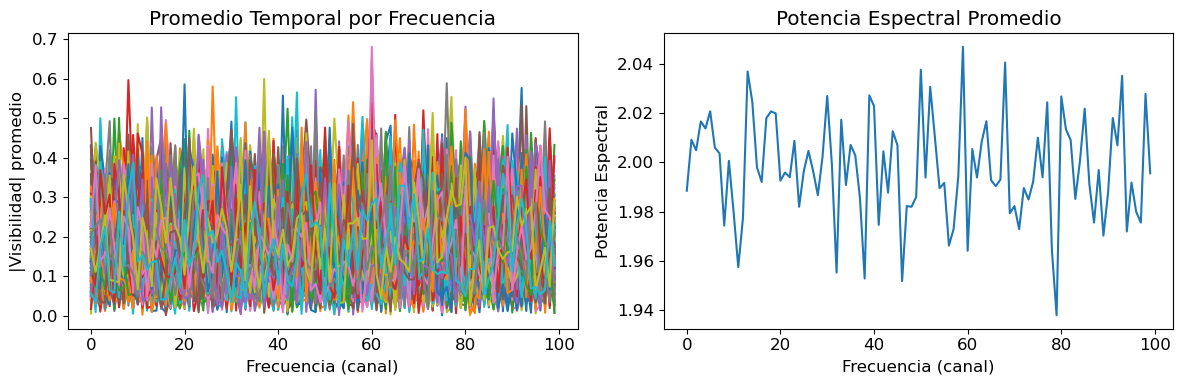

In [25]:
# ============================================
# SU CÓDIGO AQUÍ
# ============================================

# 3.1: Crear array Dask de visibilidades
def create_visibility_dask_array(n_freq=100, n_time=50, n_baseline=200, 
                                  chunk_size_freq=10, chunk_size_time=10):
    """
    Crea un array Dask de visibilidades simuladas.
    
    Parámetros:
    -----------
    n_freq : int
        Número de canales de frecuencia
    n_time : int
        Número de tiempos de observación
    n_baseline : int
        Número de baselines
    chunk_size_freq, chunk_size_time : int
        Tamaño de chunks para Dask
        
    Retorna:
    --------
    vis_dask : dask.array
        Array Dask de visibilidades (complejas)
    """
    # TODO: Crear array Dask usando da.random o da.from_array
    
    # shape de salida
    shape = (n_freq, n_time, n_baseline)
    
    # chunks
    chunks = (chunk_size_freq, chunk_size_time, n_baseline)
    
    # visibilidades con ruido gaussiano
    real_part = da.random.normal(loc=0.0, scale=1.0, size=shape, chunks=chunks)
    imag_part = da.random.normal(loc=0.0, scale=1.0, size=shape, chunks=chunks)
    
    vis_dask = real_part + 1j * imag_part
    
    return vis_dask

# 3.2: Procesar datos con Dask
def process_visibilities_dask(vis_dask):
    """
    Procesa visibilidades usando operaciones Dask.
    
    Parámetros:
    -----------
    vis_dask : dask.array
        Array Dask de visibilidades
        
    Retorna:
    --------
    time_avg : dask.array
        Promedio temporal por frecuencia
    normalized : dask.array
        Visibilidades normalizadas
    power_spectrum : dask.array
        Potencia espectral promedio
    """
    # TODO: Implementar procesamiento con Dask
    # - Promedio temporal
    # - Normalización
    # - Potencia espectral

    # promedio temporal de las visibilidades para cada frecuencia
    time_avg = vis_dask.mean(axis=1, keepdims=True)
    
    # normalización por frecuencia
    normalized = vis_dask / time_avg
    
    # potencia espectral promedio
    power = da.absolute(vis_dask)**2
    
    # promedio de la potencia espectral
    power_spectrum = power.mean(axis=(1, 2))
    
    return time_avg, normalized, power_spectrum


# ============================================
# Código de prueba
# ============================================
# Crear array
vis_dask = create_visibility_dask_array()

# Visualizar estructura
print(f"Shape: {vis_dask.shape}")
print(f"Chunks: {vis_dask.chunks}")
print(f"Size in memory (si fuera numpy): {vis_dask.nbytes / 1e9:.2f} GB")

# Procesar
time_avg, normalized, power_spectrum = process_visibilities_dask(vis_dask)

#Visualizar grafo de computación
time_avg.visualize()  # Requiere graphviz

#Computar resultados (ejecutar el grafo)
time_avg_computed = time_avg.compute()
power_spectrum_computed = power_spectrum.compute()

# Visualizar resultados
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(np.abs(time_avg_computed[:, 0]))
plt.xlabel('Frecuencia (canal)')
plt.ylabel('|Visibilidad| promedio')
plt.title('Promedio Temporal por Frecuencia')

plt.subplot(1, 2, 2)
plt.plot(power_spectrum_computed)
plt.xlabel('Frecuencia (canal)')
plt.ylabel('Potencia Espectral')
plt.title('Potencia Espectral Promedio')
plt.tight_layout()
plt.show()

### Ventajas de Dask

El uso Dask en el contexto de la radiointerferometría parte desde la naturaleza de de los datos. Principalmente por el hecho de que se trabaja con cantidades masivas de datos. Por lo tanto se listan algunas ventajas:

1. Optimización de memoria: Al permitir dividir los arrelog en pequeños *chunks*, se resuelve el problema de tener tamaños de arreglos más grande que la memoria RAM de los dispositivos.

2. Evaluación Lazy: Permite la optimización de procesos y flujos de trabajo antes de ejecutarlos. De esta forma es posible enfocarse solo en lo necesario, y no se desperdicia tiempo en cálculos innecesarios.

3. Paralelismo y escalabilidad: Muchas operaciones interferométricas son necesarmiente paralelizables. Dask permite esto sin tener que escribir un código complejo.

## Pregunta 4: Programación Orientada a Objetos y Tests (2.0 puntos)

**Contexto:** Para mantener código organizado y confiable en proyectos de radio interferometría, es importante usar programación orientada a objetos y escribir tests unitarios e de integración.

**4.1** (1.0 pts) Implemente una clase `VisibilityData` que encapsule datos de visibilidades de radio interferometría. La clase debe tener:
- Atributos: `u_coords`, `v_coords`, `visibilities`, `frequencies`, `times`
- Métodos públicos:
  - `__init__`: Constructor que valida los datos
  - `get_baseline_lengths`: Calcula las longitudes de baseline
  - `get_uv_coverage`: Retorna un mapa de cobertura UV
  - `apply_flagging`: Aplica flags (máscaras) a visibilidades ruidosas
  - `to_image`: Convierte visibilidades a imagen usando FFT (método simple)
- Métodos protegidos (usando `_`):
  - `_validate_data`: Valida que los datos de entrada sean consistentes
  - `_compute_uv_grid`: Método auxiliar para calcular el grid UV
- Métodos privados (usando `__`):
  - `__normalize_coords`: Normaliza coordenadas UV internamente
- Overriding de operadores:
  - `__add__`: Permite sumar dos objetos `VisibilityData` (suma de visibilidades)
  - `__mul__`: Permite multiplicar por un escalar (escala las visibilidades)
  - `__len__`: Retorna el número de visibilidades
  - `__eq__`: Compara dos objetos `VisibilityData` (igualdad de datos)

**4.2** (1.0 pts) Escriba tests unitarios y de integración para la clase `VisibilityData` usando `pytest`. Los tests deben cubrir:
- Inicialización correcta y validación de datos
- Cálculo de longitudes de baseline
- Aplicación de flags
- Conversión a imagen
- Overriding de operadores (`__add__`, `__mul__`, `__len__`, `__eq__`)
- Test de integración que verifique el flujo completo: crear datos → aplicar flags → convertir a imagen

**Nota:** Use `pytest` con funciones de test (no es necesario usar clases). Puede usar fixtures de pytest para datos de prueba comunes.

In [26]:
# ============================================
# SU CÓDIGO AQUÍ - Clase VisibilityData
# ============================================

class VisibilityData:
    """
    Clase para manejar datos de visibilidades en radio interferometría.
    """
    
    def __init__(self, u_coords, v_coords, visibilities, frequencies=None, times=None):
        """
        Inicializa un objeto VisibilityData.
        
        Parámetros:
        -----------
        u_coords : array 1D
            Coordenadas U en longitudes de onda
        v_coords : array 1D
            Coordenadas V en longitudes de onda
        visibilities : array 1D complejo
            Visibilidades medidas
        frequencies : array 1D, opcional
            Frecuencias en Hz
        times : array 1D, opcional
            Tiempos de observación
        """
        # TODO: Implementar constructor con validación usando _validate_data
        self.u_coords = self.__normalize_coords(u_coords)
        self.v_coords = self.__normalize_coords(v_coords)
        self.visibilities = np.array(visibilities, dtype=complex) 
        
        self.frequencies = np.array(frequencies) if frequencies is not None else None
        self.times = np.array(times) if times is not None else None
        
        self._validate_data(self.u_coords, self.v_coords, self.visibilities, 
                            self.frequencies, self.times)
    
    # Métodos públicos
    def get_baseline_lengths(self):
        """
        Calcula las longitudes de baseline.
        
        Retorna:
        --------
        baseline_lengths : array 1D
            Longitudes de baseline en longitudes de onda
        """
        # TODO: Implementar
        return np.sqrt(self.u_coords**2 + self.v_coords**2)
    
    def get_uv_coverage(self, grid_size=128):
        """
        Genera un mapa de cobertura UV.
        
        Parámetros:
        -----------
        grid_size : int
            Tamaño del grid para el mapa
            
        Retorna:
        --------
        uv_map : array 2D
            Mapa de cobertura UV
        """
        u_idx, v_idx = self._compute_uv_grid(grid_size)
        uv_map = np.zeros((grid_size, grid_size)) # grid vacio
        uv_map[u_idx, v_idx] = 1.0
        
        return uv_map
    
    def apply_flagging(self, threshold_sigma=3.0):
        """
        Aplica flags a visibilidades ruidosas basado en desviación estándar.
        
        Parámetros:
        -----------
        threshold_sigma : float
            Número de sigmas para el threshold
            
        Retorna:
        --------
        flags : array 1D booleano
            Array de flags (True = bueno, False = malo)
        """
        amplitudes = np.abs(self.visibilities)
        mean_val = np.mean(amplitudes)
        std_val = np.std(amplitudes)
        
        # Definir el límite superior e inferior
        upper_limit = mean_val + threshold_sigma * std_val
        lower_limit = mean_val - threshold_sigma * std_val
        
        # Crear máscara: True si está DENTRO de los límites (dato bueno)
        flags = (amplitudes >= lower_limit) & (amplitudes <= upper_limit)
        
        return flags
    
    def to_image(self, image_size=128, pixel_scale=0.1):
        """
        Convierte visibilidades a imagen usando FFT simple.
        
        Parámetros:
        -----------
        image_size : int
            Tamaño de la imagen de salida
        pixel_scale : float
            Escala del pixel en arcsec
            
        Retorna:
        --------
        image : array 2D
            Imagen reconstruida
        """
        # TODO: Implementar conversión a imagen
        grid = np.zeros((image_size, image_size), dtype=complex)
        u_idx, v_idx = self._compute_uv_grid(image_size)
        
        np.add.at(grid, (u_idx, v_idx), self.visibilities)
        
        # fft
        f_shifted = np.fft.ifftshift(grid) 
        image_complex = np.fft.ifft2(f_shifted)
        image_centered = np.fft.fftshift(image_complex)
        
        return np.real(image_centered)
    
    # Métodos protegidos (usando _)
    def _validate_data(self, u_coords, v_coords, visibilities, frequencies=None, times=None):
        """
        Valida que los datos de entrada sean consistentes.
        
        Parámetros:
        -----------
        u_coords, v_coords, visibilities : arrays
            Datos a validar
        frequencies, times : arrays, opcional
            Datos opcionales a validar
            
        Lanza:
        ------
        ValueError
            Si los datos no son consistentes
        """
        # TODO: Implementar validación
        n_vis = len(visibilities)
        
        if len(u_coords) != n_vis or len(v_coords) != n_vis:
            raise ValueError(f"Dimensión incorrecta: u,v ({len(u_coords)}) != vis ({n_vis})")
            
        if frequencies is not None and len(frequencies) == 0:
            pass
    
    def _compute_uv_grid(self, grid_size):
        """
        Calcula el grid UV para el mapa de cobertura.
        
        Parámetros:
        -----------
        grid_size : int
            Tamaño del grid
            
        Retorna:
        --------
        u_grid, v_grid : arrays 2D
            Grids de coordenadas U y V
        """
        # TODO: Implementar
        max_uv = np.max([np.abs(self.u_coords).max(), np.abs(self.v_coords).max()])
        
        # Evita división por cero
        if max_uv == 0: max_uv = 1.0
            
        normalized_u = (self.u_coords / (2 * max_uv)) + 0.5
        normalized_v = (self.v_coords / (2 * max_uv)) + 0.5
        
        u_idx = (normalized_u * (grid_size - 1)).astype(int)
        v_idx = (normalized_v * (grid_size - 1)).astype(int)
        
        # eitar índices fuera de rango
        u_idx = np.clip(u_idx, 0, grid_size - 1)
        v_idx = np.clip(v_idx, 0, grid_size - 1)
        
        return u_idx, v_idx
    
    # Métodos privados (usando __)
    def __normalize_coords(self, coords):
        """
        Normaliza coordenadas internamente.
        
        Parámetros:
        -----------
        coords : array 1D
            Coordenadas a normalizar
            
        Retorna:
        --------
        normalized_coords : array 1D
            Coordenadas normalizadas
        """
        # TODO: Implementar normalización
        return np.array(coords, dtype=np.float64)
    
    # Overriding de operadores
    def __add__(self, other):
        """
        Suma dos objetos VisibilityData.
        
        Parámetros:
        -----------
        other : VisibilityData
            Otro objeto VisibilityData a sumar
            
        Retorna:
        --------
        result : VisibilityData
            Nuevo objeto con visibilidades sumadas
        """
        # TODO: Implementar suma de visibilidades
        if not isinstance(other, VisibilityData):
            raise TypeError("Solo se pueden sumar objetos VisibilityData entre sí.")
            
        if not (np.allclose(self.u_coords, other.u_coords) and 
                np.allclose(self.v_coords, other.v_coords)):
            raise ValueError("No se pueden sumar: Las coordenadas UV no coinciden.")
            
        new_vis = self.visibilities + other.visibilities
        
        return VisibilityData(
            self.u_coords, 
            self.v_coords, 
            new_vis, 
            self.frequencies, 
            self.times
        )
    
    def __mul__(self, scalar):
        """
        Multiplica las visibilidades por un escalar.
        
        Parámetros:
        -----------
        scalar : float o complex
            Escalar para multiplicar
            
        Retorna:
        --------
        result : VisibilityData
            Nuevo objeto con visibilidades escaladas
        """
        # TODO: Implementar multiplicación por escalar
        if not (isinstance(scalar, (int, float, complex))):
            raise TypeError("El multiplicador debe ser un escalar numérico.")
            
        new_vis = self.visibilities * scalar
        
        return VisibilityData(
            self.u_coords, 
            self.v_coords, 
            new_vis, 
            self.frequencies, 
            self.times
        )
    
    def __len__(self):
        """
        Retorna el número de visibilidades.
        
        Retorna:
        --------
        length : int
            Número de visibilidades
        """
        # TODO: Implementar
        return len(self.visibilities)
    
    def __eq__(self, other):
        """
        Compara dos objetos VisibilityData.
        
        Parámetros:
        -----------
        other : VisibilityData
            Otro objeto a comparar
            
        Retorna:
        --------
        is_equal : bool
            True si los datos son iguales
        """
        # TODO: Implementar comparación
        if not isinstance(other, VisibilityData):
            return False
            
        return (np.allclose(self.u_coords, other.u_coords) and
                np.allclose(self.v_coords, other.v_coords) and
                np.allclose(self.visibilities, other.visibilities))

In [27]:
# ============================================
# SU CÓDIGO AQUÍ - Tests con pytest
# ============================================


# Fixture de pytest para datos de prueba comunes
@pytest.fixture
def sample_visibility_data():
    """
    Fixture que crea datos de visibilidades de ejemplo.
    """
    # TODO: Crear y retornar un objeto VisibilityData de ejemplo
    np.random.seed(42)
    n_points = 1000
    
    u = np.random.uniform(-100, 100, n_points)
    v = np.random.uniform(-100, 100, n_points)
    
    vis = np.random.normal(0, 1, n_points) + 1j * np.random.normal(0, 1, n_points)
    
    return VisibilityData(u, v, vis)

@pytest.fixture
def sample_visibility_data_2(sample_visibility_data):
    """
    Fixture que crea un segundo conjunto de datos para pruebas de operadores.
    """
    # TODO: Crear y retornar otro objeto VisibilityData de ejemplo
    u = sample_visibility_data.u_coords.copy()
    v = sample_visibility_data.v_coords.copy()
    
    vis = np.ones(len(u), dtype=complex) * 2.0
    
    return VisibilityData(u, v, vis)

# Tests unitarios
def test_initialization(sample_visibility_data):
    """Test de inicialización correcta."""
    # TODO: Verificar que la inicialización funciona correctamente
    assert len(sample_visibility_data.u_coords) == 1000
    assert len(sample_visibility_data.visibilities) == 1000
    assert sample_visibility_data.visibilities.dtype == np.complex128 or np.complex64

def test_initialization_validation():
    """Test de validación en inicialización."""
    # TODO: Verificar que se lanzan errores apropiados con datos inválidos
    # Ejemplo: longitudes inconsistentes, tipos incorrectos, etc.
    u_bad = np.zeros(1000)
    v_bad = np.zeros(1000)
    vis_bad = np.zeros(999) # Uno menos
    
    with pytest.raises(ValueError):
        VisibilityData(u_bad, v_bad, vis_bad)

def test_baseline_lengths(sample_visibility_data):
    """Test de cálculo de longitudes de baseline."""
    # TODO: Verificar que get_baseline_lengths() retorna valores correctos
    lengths = sample_visibility_data.get_baseline_lengths()
    
    # valor esperado
    expected = np.sqrt(sample_visibility_data.u_coords**2 + sample_visibility_data.v_coords**2)
    
    np.testing.assert_allclose(lengths, expected, rtol=1e-5)
    
    assert len(lengths) == 1000

def test_uv_coverage(sample_visibility_data):
    """Test de generación de mapa UV."""
    # TODO: Verificar que get_uv_coverage() genera un mapa correcto
    grid_size = 256 
    uv_map = sample_visibility_data.get_uv_coverage(grid_size=grid_size)
    
    assert uv_map.shape == (grid_size, grid_size)
    assert np.sum(uv_map) > 0

def test_flagging(sample_visibility_data):
    """Test de aplicación de flags."""
    # TODO: Verificar que apply_flagging() funciona correctamente
    # Verificar que los flags identifican datos ruidosos apropiadamente
    sample_visibility_data.visibilities[:10] = 1e6 + 0j
    
    # flagging
    flags = sample_visibility_data.apply_flagging(threshold_sigma=5.0)
    
    assert np.all(flags[:10] == False)
    assert np.sum(flags) > 900

def test_to_image(sample_visibility_data):
    """Test de conversión a imagen."""
    # TODO: Verificar que to_image() genera una imagen válida
    img_size = 128
    image = sample_visibility_data.to_image(image_size=img_size)
    assert image.shape == (img_size, img_size)
    assert np.all(np.isfinite(image))

# Tests de operadores
def test_add_operator(sample_visibility_data, sample_visibility_data_2):
    """Test del operador __add__."""
    # TODO: Verificar que se pueden sumar dos objetos VisibilityData
    # Verificar que las coordenadas UV deben ser compatibles
    res = sample_visibility_data + sample_visibility_data_2
    
    # Verificación manual
    expected_vis = sample_visibility_data.visibilities + sample_visibility_data_2.visibilities
    np.testing.assert_allclose(res.visibilities, expected_vis)
    assert len(res) == 1000

def test_mul_operator(sample_visibility_data):
    """Test del operador __mul__."""
    # TODO: Verificar que se puede multiplicar por un escalar
    # Verificar con diferentes tipos de escalares (int, float, complex)
    # 1. Int
    scalar_int = 2
    res_int = sample_visibility_data * scalar_int
    
    expected_int = sample_visibility_data.visibilities * scalar_int
    np.testing.assert_allclose(res_int.visibilities, expected_int)
    assert np.iscomplexobj(res_int.visibilities)

    # 2. Float
    scalar_float = 0.5
    res_float = sample_visibility_data * scalar_float
    
    expected_float = sample_visibility_data.visibilities * scalar_float
    np.testing.assert_allclose(res_float.visibilities, expected_float)

    # 3. Coplex
    scalar_complex = 1j
    res_complex = sample_visibility_data * scalar_complex
    
    # manual verif.
    expected_complex = sample_visibility_data.visibilities * scalar_complex
    np.testing.assert_allclose(res_complex.visibilities, expected_complex)
    

def test_len_operator(sample_visibility_data):
    """Test del operador __len__."""
    # TODO: Verificar que len() retorna el número correcto de visibilidades
    assert len(sample_visibility_data) == 1000

def test_eq_operator(sample_visibility_data):
    """Test del operador __eq__."""
    # TODO: Verificar que == funciona correctamente
    # Crear un objeto idéntico y verificar que son iguales
    # Crear un objeto diferente y verificar que no son iguales
    copy_data = VisibilityData(
        sample_visibility_data.u_coords,
        sample_visibility_data.v_coords,
        sample_visibility_data.visibilities
    )
    assert sample_visibility_data == copy_data

# Test de integración
def test_integration_workflow(sample_visibility_data):
    """Test de integración: flujo completo."""
    # TODO: Test completo del flujo de trabajo:
    # 1. Crear objeto VisibilityData
    # 2. Aplicar flags
    # 3. Filtrar visibilidades usando flags
    # 4. Convertir a imagen
    # 5. Verificar que la imagen es válida
    
    # datos sinteticos
    n_points = 10000
    u = np.random.normal(0, 50, n_points)
    v = np.random.normal(0, 50, n_points)
    # Señal débil + Ruido
    vis = np.random.normal(0, 1, n_points) + 1j * np.random.normal(0, 1, n_points)
    
    # RFI
    vis[0:50] = 10000.0 + 10000.0j
    dataset = VisibilityData(u, v, vis)
    
    # Flagging
    print(f"\nDatos iniciales: {len(dataset)}")
    flags = dataset.apply_flagging(threshold_sigma=4.0)
    
    n_good = np.sum(flags)
    n_bad = len(flags) - n_good
    print(f"Datos buenos: {n_good}, Datos flaggeados (RFI): {n_bad}")
    
    # Verificar que detectamos al menos los 50 malos
    assert n_bad >= 50
    
    # Filter
    clean_data = VisibilityData(
        dataset.u_coords[flags],
        dataset.v_coords[flags],
        dataset.visibilities[flags]
    )
    
    # Imagen
    image = clean_data.to_image(image_size=256)
    
    # Validaciones finales
    assert image.shape == (256, 256)
    assert len(clean_data) == n_good
    
    print("Integration workflow test completado")

# ============================================
# Ejecutar tests
# ============================================
# Para ejecutar los tests, use en terminal:
# pytest pep2_vmieres.ipynb -v
# O dentro del notebook:
# !pytest pep2_vmieres.ipynb -v


In [29]:
ipytest.run('-vv')

======================================= test session starts ========================================
platform linux -- Python 3.13.7, pytest-9.0.2, pluggy-1.6.0 -- /home/vcnt/y/envs/lab2_env/bin/python
cachedir: .pytest_cache
rootdir: /home/vcnt/Repositories/RadioInterferometry/pep2
plugins: anyio-4.12.0
collecting ... collected 11 items

t_68fb3f84d9fa4f59a045c992a62f73a5.py::test_initialization PASSED                            [  9%]
t_68fb3f84d9fa4f59a045c992a62f73a5.py::test_initialization_validation PASSED                 [ 18%]
t_68fb3f84d9fa4f59a045c992a62f73a5.py::test_baseline_lengths PASSED                          [ 27%]
t_68fb3f84d9fa4f59a045c992a62f73a5.py::test_uv_coverage PASSED                               [ 36%]
t_68fb3f84d9fa4f59a045c992a62f73a5.py::test_flagging PASSED                                  [ 45%]
t_68fb3f84d9fa4f59a045c992a62f73a5.py::test_to_image PASSED                                  [ 54%]
t_68fb3f84d9fa4f59a045c992a62f73a5.py::test_add_operator PA

<ExitCode.OK: 0>